# Lecture 1: micrograd — 反向传播与自动微分引擎

本笔记跟随 Andrej Karpathy 的 *Neural Networks: Zero to Hero* 课程第一讲，
从零开始实现一个微型自动微分引擎（**micrograd**），并用它训练一个小型神经网络。

**学习路线：**
1. 导数的数值定义（极限）
2. 偏导数与多变量函数
3. `Value` 类 —— 构建计算图 + 自动求梯度
4. 反向传播（backpropagation）
5. 神经网络的层级结构（Neuron → Layer → MLP）
6. 训练循环：前向传播 → 损失 → 反向传播 → 参数更新

In [2]:
# ============================================================
# 导入基础库
# ============================================================
import math          # 数学函数库，提供 exp, log 等（用于 tanh、exp 运算）
import numpy as np   # 数值计算库，提供数组操作（用于生成数据、随机初始化权重）
import matplotlib.pyplot as plt  # 绑图库，用于可视化函数曲线
# 让 matplotlib 的图直接显示在 notebook 里，而不是弹出新窗口
%matplotlib inline

## 1. 导数与数值微分

**导数的直觉理解：** 导数衡量的是“当输入发生微小变化时，输出会怎样变化”。

用数学语言表示：

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**生活类比：** 把 $f(x)$ 想象成你开车时的位置，$x$ 是时间。
那么导数 $f'(x)$ 就是你当前的**速度** —— 位置变化的快慢。

- 导数 > 0：函数在上升（你在前进）
- 导数 < 0：函数在下降（你在后退）
- 导数 = 0：函数到达极值点（你停下来了）

在代码中，我们用一个很小的 `h`（如 0.0000001）来**近似**这个极限，这就是“数值微分”。

In [3]:
# ============================================================
# 定义一个简单的二次函数 f(x) = 3x² - 4x + 5
# 这是一个抛物线，最低点（极值点）在 x = 2/3 处
# 用这个函数来演示导数（斜率）的概念
# ============================================================
def f(x):
    return 3*x**2-4*x+5

In [4]:
# 计算 f(3.0) = 3*(3)^2 - 4*(3) + 5 = 27 - 12 + 5 = 20.0
f(3.0)

20.0

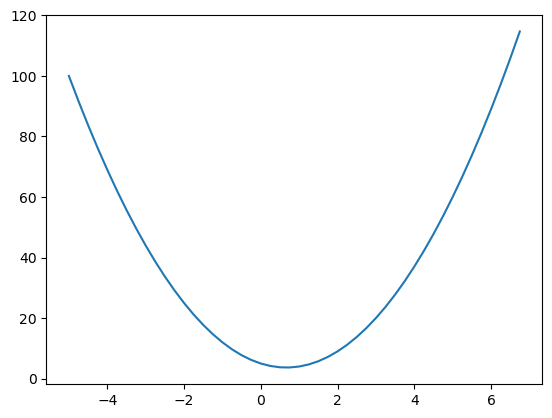

In [5]:
# ============================================================
# 画出 f(x) 的图像，直观看到函数的形状
# ============================================================
xs=np.arange(-5,7,0.25)  # 生成 x 轴数据：从 -5 到 7，步长 0.25
ys=f(xs)                  # 对每个 x 计算 f(x)，numpy 支持向量化运算
plt.plot(xs,ys)           # 绑制曲线
plt.show() 
# 为什么需要plt.show()？
# 因为在某些环境中（如Jupyter Notebook）需要调用plt.show()来显示图形
# plt.show()会阻止代码继续执行，直到图形窗口被关闭

In [6]:
# ============================================================
# 用数值法（极限定义）计算 f(x) 在 x=2/3 处的导数
# 导数定义：f'(x) = lim(h→0) [f(x+h) - f(x)] / h
# ============================================================
h=0.0000001          # h 越小，数值导数越接近真实导数
x=2/3                # x=2/3 是抛物线最低点，导数应该 ≈ 0
print(f(x))          # f(2/3) = 3*(4/9) - 4*(2/3) + 5 = 11/3 ≈ 3.667
print(f(x+h))        # f(2/3 + h)，比 f(2/3) 大一点点
print((f(x+h)-f(x))/h)  # 数值导数 ≈ 0（极值点处斜率为 0）

3.666666666666667
3.6666666666666967
2.9753977059954195e-07


## 2. 偏导数与多变量函数

当函数有多个输入变量时，我们需要分别考察每个变量对输出的影响 —— 这就是**偏导数**。

对于 $d = a \cdot b + c$：

$$\frac{\partial d}{\partial a} = b, \quad \frac{\partial d}{\partial b} = a, \quad \frac{\partial d}{\partial c} = 1$$

**计算方法：** 求某个变量的偏导数时，把其他变量当作常数。

**类比：** 假设你在调音响（$d$ = 音量）：
- $a$ 是左声道旋钮，$b$ 是右声道旋钮，$c$ 是总音量旋钮
- 偏导数告诉你：转动**某一个**旋钮时，总音量会变化多少
- 而其他旋钮保持不动

这个概念对于理解神经网络的梯度至关重要：训练时我们需要知道每个参数（权重、偏置）
对最终损失的影响有多大。

In [7]:
# ============================================================
# 多变量表达式：d = a*b + c
# 接下来要分别对 a, b, c 求偏导数（partial derivative）
# 偏导数的意义：某个变量变化一点点，结果 d 会变化多少？
# ============================================================
a=2.0
b=-3.0
c=10.0
d=a*b+c   # d = 2*(-3) + 10 = 4.0
print(d)

4.0


In [8]:
# ============================================================
# 用数值法求 d = a*b + c 对各变量的偏导数
# 方法：只给一个变量加上微小的 h，其余不动，观察 d 的变化量
#
# 数学推导：
#   ∂d/∂a = b = -3.0        （a 每增加 1，d 增加 b）
#   ∂d/∂b = a = 2.0         （b 每增加 1，d 增加 a）
#   ∂d/∂c = 1.0             （c 每增加 1，d 增加 1）
# ============================================================
h=0.0001

a=2.0
b=-3.0
c=10.0
d1=a*b+c               # 原始值 d1 = 4.0
print('d1=',d1)

# 试试给 c 加一个微小增量 h（把 a+=h 或 b+=h 的注释去掉可以测试其他变量）
# a+=h   # 取消注释 → slope ≈ -3.0（即 ∂d/∂a = b）
# b+=h   # 取消注释 → slope ≈ 2.0 （即 ∂d/∂b = a）
c+=h     # 当前测试 c → slope ≈ 1.0 （即 ∂d/∂c = 1）

d2=a*b+c               # 加了 h 之后的新值
print('d2=',d2)

print('slope=',(d2-d1)/h)  # 数值偏导数 = (d2 - d1) / h

d1= 4.0
d2= 4.0001
slope= 0.9999999999976694


## 3. 计算图与自动微分（Autograd）

**核心问题：** 当表达式变得复杂时（成千上万个参数），手动算偏导数不现实。
我们需要让计算机**自动**计算梯度。

**解决方案：计算图（Computation Graph）**

每次做运算时，不仅算出结果，还记录"这个结果是怎么算出来的"：

```
a = Value(2.0)    # 叶子节点
b = Value(3.0)    # 叶子节点
c = a + b         # c 记住了：我 = a + b
d = c * a         # d 记住了：我 = c * a
```

这样所有运算就构成了一张**有向无环图（DAG, Directed Acyclic Graph）**。有了这张图，
就可以用**链式法则**从输出到输入自动传播梯度。

下面的 `Value` 类就是这个思想的实现。每个 `Value` 对象存储了：
- `data`：数值
- `grad`：梯度（通过反向传播计算）
- `_prev`：产生它的父节点（构建计算图）
- `_backward`：反向传播时如何把梯度传给父节点

In [9]:
# ============================================================
# Value 类：自动微分引擎的核心
#
# 核心思想：
#   每个 Value 对象不仅存储一个数值(data)，还记录了它是怎么算出来的
#   （由哪些 Value 通过什么运算产生），从而构建一张"计算图"。
#   有了计算图，就可以用链式法则自动计算梯度（反向传播）。
#
# 示例计算图：
#   a=2, b=3 → c=a+b=5 → d=c*2=10
#   c._prev = {a, b},  c._op = '+'
#   d._prev = {c, 2},  d._op = '*'
#   调用 d.backward() 后，a.grad 和 b.grad 就自动算好了
# ============================================================

class Value:
    # ---- 构造函数 ----
    # __init__是一个特殊方法，用于在创建对象时初始化对象的属性。
    # self是一个指向当前对象的引用，允许我们在类的方法中访问对象的属性和方法。
    def __init__(self,data,_children=(),_op='',label=''): 
        self.data=data          # 存储的数值（标量）
        self.grad=0.0           # 该节点的梯度，初始为 0（backward 后会被填充）
        self._backward=lambda:None  # 反向传播函数，叶子节点默认什么都不做
        self._prev=set(_children)   # 父节点集合（产生本节点的那些节点）
        self._op=_op            # 产生本节点的运算符（'+', '*', 'tanh' 等），用于可视化
        self.label=label        # 节点标签，用于调试和可视化

    # ---- 打印表示 ----
    # __repr__是一个特殊方法，用于定义对象的字符串表示。
    # 当我们打印一个对象或者使用str()函数时，__repr__方法会被调用。
    def __repr__(self):
        return f"Value(data={self.data})"
    
    # ---- 加法：self + other ----
    # 当写 a + b 时，Python 自动调用 a.__add__(b)
    def __add__(self,other):
        # 如果 other 不是 Value（比如普通数字 2.0），自动包装成 Value
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),'+')

        def _backward():
            # 加法的导数：d(a+b)/da = 1, d(a+b)/db = 1
            # 链式法则：用 out.grad 乘以局部导数
            # 用 += 而不是 = ，因为一个节点可能被多条路径使用，梯度需要累加
            self.grad+=out.grad*1.0
            other.grad+=out.grad*1.0
        out._backward=_backward

        return out
    
    # ---- 反向加法：other + self ----
    # 当 other 不是 Value 时（如 2 + a），Python 先试 (2).__add__(a) 失败，
    # 然后会调用 a.__radd__(2)
    def __radd__(self, other):
        return self+other

    # ---- 乘法：self * other ----
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),'*')

        def _backward():
            # 乘法的导数（交叉求导）：
            #   d(a*b)/da = b    → self.grad += other.data * out.grad
            #   d(a*b)/db = a    → other.grad += self.data * out.grad
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward

        return out
    
    # ---- 幂运算：self ** other ----
    # 只支持 other 为常数（int/float），不支持 Value**Value
    def __pow__(self, other):
        assert isinstance(other,(int,float)),"only supporting int/float powers for now"
        out=Value(self.data**other,(self,),f'**{other}')

        def _backward():
            # 幂函数的导数：d(x^n)/dx = n * x^(n-1)
            # 链式法则：再乘以 out.grad
            self.grad+=other*(self.data**(other-1))*out.grad
        out._backward=_backward

        return out
    
    # ---- 反向乘法：other * self ----
    def __rmul__(self, other):
        return self*other
    
    # ---- 除法：self / other ----
    def __truediv__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data/other.data,(self,other),'/')

        def _backward():
            # 除法的导数：d(a/b)/da = 1/b,  d(a/b)/db = -a/b²
            self.grad+=out.grad*(1/other.data)
            other.grad+=out.grad*(-self.data/(other.data**2))
        out._backward=_backward

        return out
    
    # ---- 反向除法：other / self ----
    # 比如 2 / a → 先尝试 (2).__truediv__(a) 失败 → 调用 a.__rtruediv__(2)
    def __rtruediv__(self, other):
        other=other if isinstance(other,Value) else Value(other)
        return other/self
    
    # ---- 取负：-self ----
    def __neg__(self):
        return self*(-1)  # 复用乘法实现
    
    # ---- 减法：self - other ----
    def __sub__(self, other):
        return self+(-other)  # 复用加法和取负
    
    # ---- 反向减法：other - self ----
    def __rsub__(self, other):
        other=other if isinstance(other,Value) else Value(other)
        return other-self

    # ---- tanh 激活函数 ----
    # tanh(x) = (e^(2x) - 1) / (e^(2x) + 1)，输出范围 (-1, 1)
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),'tanh')

        def _backward():
            # tanh 的导数：d(tanh(x))/dx = 1 - tanh²(x)
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward

        return out
    
    # ---- 指数函数 e^x ----
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')

        def _backward():
            # exp 的导数：d(e^x)/dx = e^x = out.data
            self.grad+=out.data*out.grad
        out._backward=_backward

        return out
    
    # ---- 反向传播（自动求导的核心）----
    # 从当前节点出发，自动计算计算图中所有节点的梯度
    def backward(self):
        # 第 1 步：拓扑排序
        # 确保每个节点在其所有子节点之后才被处理
        # 这样反转后，就能从输出到输入依次传播梯度
        topo=[]; 
        visited=set() 
        def build_topo(v): 
            if v not in visited: 
                visited.add(v) 
                for child in v._prev: 
                    build_topo(child)  # 先递归处理所有子节点
                topo.append(v)         # 子节点都处理完了，再加入自己
        build_topo(self)  # 从当前节点（通常是 loss）开始构建

        # 第 2 步：从输出向输入反向传播梯度
        self.grad=1.0  # 输出节点对自身的导数 = 1（dloss/dloss = 1）
        for node in reversed(topo):  # 按拓扑逆序遍历
            node._backward()  # 调用每个节点的 _backward，把梯度传给它的父节点

In [10]:
# ============================================================
# 测试 Value 类的各种运算符重载是否正常工作
# ============================================================
a=Value(2.0)
b=Value(-4.0)
# 测试复合表达式：1 - a^(int(2-b的值)) / b - 1
# 这里会触发 __rsub__, __pow__, __truediv__, __sub__ 等多种运算
1-a**int((2-b).data)/b-1
# 测试 tanh 激活函数
a.tanh()

Value(data=0.9640275800758169)

### 计算图的可视化

为了直观地看到 `Value` 对象之间的计算关系，我们用 `graphviz` 库来画图。

图中每个**矩形框**是一个 `Value` 节点，显示三个信息：
- **label**：变量名（如 x1, w1）
- **data**：数值（前向传播的结果）
- **grad**：梯度（反向传播后的结果）

每个**圆形节点**是一个运算符（+, *, tanh 等），箭头从左到右表示数据的流向。

In [11]:
# ============================================================
# 计算图可视化工具
# 用 graphviz 画出 Value 对象之间的计算关系
# ============================================================
from graphviz import Digraph 

def trace(root): 
    """
    从根节点出发，深度优先搜索遍历整个计算图
    返回：(nodes, edges) — 所有节点的集合 和 所有边的集合
    
    例如 d = a*b + c：
        nodes = {a, b, c, a*b, d}
        edges = {(a, a*b), (b, a*b), (a*b, d), (c, d)}
    """
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:      # 遍历所有父节点（产生 v 的节点）
                edges.add((child, v))   # 记录边：child → v
                build(child)            # 递归遍历
    build(root)
    return nodes, edges

def draw_dot(root):
    """
    画出计算图的可视化：
    - 每个 Value 显示为矩形框，包含 label、data、grad 三列
    - 每个运算符显示为圆形节点（+, *, tanh 等）
    - 箭头从左到右表示数据流向（LR = Left to Right）
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))  # 用对象的内存地址作为唯一 ID
        # 创建 record 形状的节点：| label | data | grad |
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # 如果该节点是某个运算的结果，额外创建一个运算符节点
            dot.node(name=uid + n._op, label=n._op)
            # 运算符节点 → 结果节点
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # 父节点 → 运算符节点（而不是直接连到结果节点）
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

## 4. 反向传播与链式法则

**链式法则（Chain Rule）** 是反向传播的数学基础。

假设 $y = f(g(x))$，即 $y$ 依赖于 $u = g(x)$，而 $u$ 又依赖于 $x$，那么：

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

**直觉理解：** 如果 $x$ 变化 1，$u$ 变化 3（$du/dx=3$），
而 $u$ 变化 1 时 $y$ 变化 2（$dy/du=2$），
那么 $x$ 变化 1 时 $y$ 变化 $3 \times 2 = 6$。

**反向传播的流程：**
1. 先完成前向传播，计算出所有节点的 `data`
2. 将输出节点的梯度设为 1（$\partial \text{loss} / \partial \text{loss} = 1$）
3. 按拓扑逆序遍历计算图，每个节点把梯度传给它的父节点
4. 传播完成后，每个节点的 `.grad` 就是输出对它的偏导数

下面我们手动构建一个神经元，观察前向传播和反向传播的完整过程。

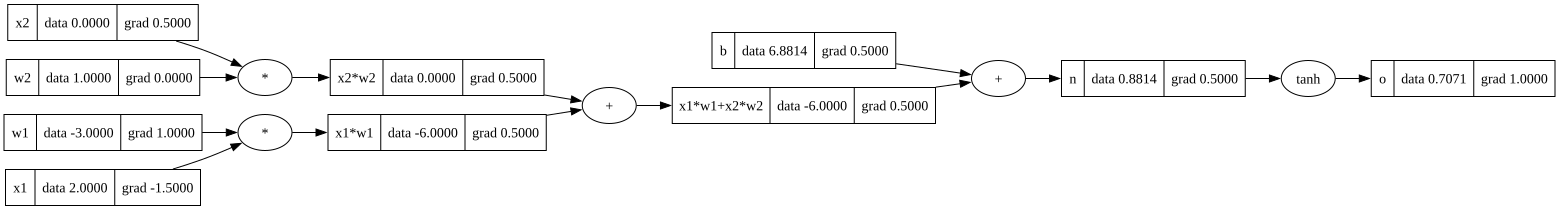

In [12]:
# ============================================================
# 手动构建一个神经元的前向传播 + 反向传播
#
# 这个神经元有 2 个输入(x1,x2)、2 个权重(w1,w2)、1 个偏置(b)
# 输出：o = tanh(x1*w1 + x2*w2 + b)
#
# 计算图：
#   x1 ─┐         ┌──────┐
#       ├─(*w1)──┐│      │
#   w1 ─┘        ├┤ (+)  ├──(+b)──► n ──(tanh)──► o
#   x2 ─┐        ├┤      │
#       ├─(*w2)──┘│      │
#   w2 ─┘         └──────┘
# ============================================================
x1= Value(2.0,label='x1')
x2= Value(0.0, label='x2')
w1= Value(-3.0,label='w1')
w2= Value(1.0,label='w2')
# 偏置 b 的值经过精心选择，使得 n = x1*w1 + x2*w2 + b = 0.8814...
# 这样 tanh(n) = 0.7071... ≈ 1/√2，方便验证梯度
b= Value(6.8813735870195432,label='b')

x1w1=x1*w1; x1w1.label='x1*w1'            # x1*w1 = 2*(-3) = -6
x2w2=x2*w2; x2w2.label='x2*w2'            # x2*w2 = 0*1 = 0
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1+x2*w2'  # -6 + 0 = -6
n=x1w1x2w2+b; n.label='n'                 # -6 + 6.881 = 0.881
o=n.tanh(); o.label='o'                    # tanh(0.881) ≈ 0.707

o.backward()    # 反向传播：从 o 开始，自动计算所有节点的梯度
draw_dot(o)     # 画出计算图，每个节点显示 data 和 grad

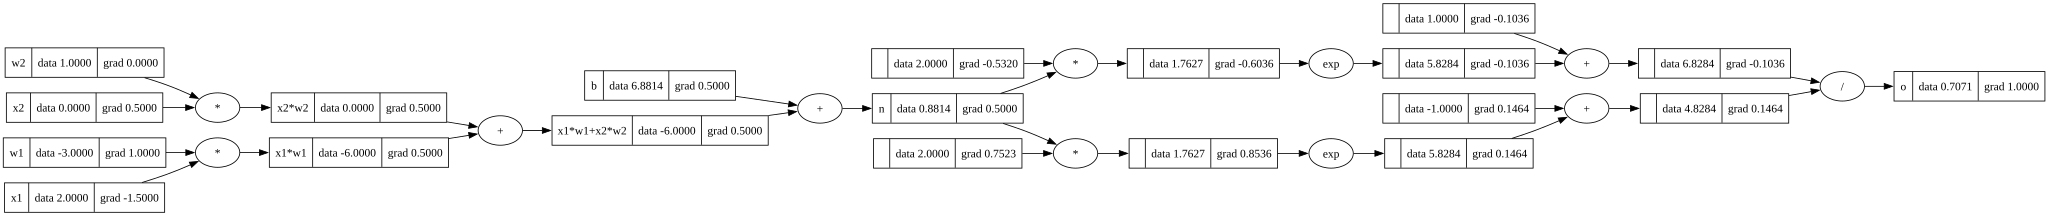

In [13]:
# ============================================================
# 同一个神经元，但用基本运算（exp, +, -, /）分解 tanh
# 验证：手动拆开 tanh 和直接调用 .tanh() 结果完全一样
#
# tanh(x) = (e^(2x) - 1) / (e^(2x) + 1)
# 这样计算图会更细粒度，能看到 exp、加减乘除每一步的梯度
# ============================================================
x1= Value(2.0,label='x1')
x2= Value(0.0, label='x2')
w1= Value(-3.0,label='w1')
w2= Value(1.0,label='w2')
b= Value(6.8813735870195432,label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b; n.label='n'

# 手动实现 tanh：不调用 n.tanh()，而是用 exp、+、-、/ 拆开
# o = (e^(2n) - 1) / (e^(2n) + 1)
o=((2*n).exp()-1)/((2*n).exp()+1); 
o.label='o'

o.backward()    # 反向传播
draw_dot(o)     # 计算图会比上面的更详细（更多中间节点）

### 用 PyTorch 验证我们的实现

PyTorch 是工业级的深度学习框架，内置了高度优化的自动微分引擎。

我们用 PyTorch 重做相同的计算，如果梯度值完全一致，就说明我们的 `Value` 类实现正确。
这是一种很好的**测试驱动开发**思路：用权威实现来验证自己的代码。

In [14]:
# 导入 PyTorch —— 工业级深度学习框架
# 用 PyTorch 重做同样的计算，验证我们自己写的 Value 类梯度是否正确
import torch

In [15]:
# ============================================================
# 用 PyTorch 重做上面的神经元计算，对比梯度值
# 如果两者梯度一致，说明我们的 Value 类实现是正确的！
# ============================================================

# 创建 PyTorch 张量，.double() 用双精度；requires_grad=True 启用自动求导
x1 =torch.Tensor([2.0]).double() ; x1.requires_grad = True ;
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True ;
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True ;
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True ;
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True ;

n = x1*w1 + x2*w2 + b         # 前向传播：加权和
o = torch.tanh(n)              # tanh 激活
print(o.data.item())           # 打印 o 的值（应该 ≈ 0.7071）

o.backward()                   # PyTorch 的反向传播

# 打印每个变量的梯度，应该和我们 Value 类的结果完全一致
print("--")
print('x2', x2.grad.item())   # ∂o/∂x2
print('w2', w2.grad.item())   # ∂o/∂w2
print('x1', x1.grad.item())   # ∂o/∂x1
print('w1', w1.grad.item())   # ∂o/∂w1
print('b', b.grad.item())     # ∂o/∂b

0.7071066904050358
--
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737
b 0.5000001283844369


## 5. 神经网络的层级结构

神经网络由三个层次的抽象构成：

### Neuron（神经元）—— 最小计算单元

$$y = \tanh\left(\sum_{i=1}^{n} w_i \cdot x_i + b\right)$$

每个神经元接收多个输入，计算加权和，再通过激活函数输出一个标量。

### Layer（层）—— 多个并行的神经元

一层包含多个神经元，它们接收相同的输入，各自独立计算，产生多个输出。

### MLP（多层感知机）—— 多层串联

将多个层串联起来：前一层的输出作为后一层的输入。

```
输入 → [Layer 0] → [Layer 1] → ... → [Layer N] → 输出
```

**为什么需要多层？** 单层只能拟合线性关系。
多层 + 非线性激活函数（如 tanh）让网络能学习复杂的非线性映射。

**类比：** 把神经网络想象成一个工厂流水线：
- 每个工人（神经元）做一个简单的判断
- 一组工人（层）并行工作
- 多道工序（多层）串联，最终产出成品

In [17]:
import random

# ============================================================
# 神经网络的三层抽象：Neuron → Layer → MLP
# 
# 结构示意（以 MLP(3, [4, 4, 1]) 为例）：
#
#   输入层(3)      隐藏层1(4)     隐藏层2(4)     输出层(1)
#   x1 ──────►  [n1, n2, n3, n4] ──► [n1, n2, n3, n4] ──► [n1] ──► y
#   x2 ──────►                                              
#   x3 ──────►                                              
#
# 每个箭头 ──► 都代表"全连接"：前一层的所有输出都作为下一层每个神经元的输入
# ============================================================

class Neuron:
    """
    单个神经元：接收 nin 个输入，输出 1 个标量值
    数学公式：y = tanh(w1*x1 + w2*x2 + ... + wn*xn + b)
    
    示意图（nin=3 的情况）：
        x1 ──w1──┐
        x2 ──w2──┼──► Σ(wi*xi) + b ──► tanh ──► y
        x3 ──w3──┘
    """
    def __init__(self, nin):
        # nin = number of inputs，即这个神经元有多少个输入
        
        # 为每个输入创建一个权重(weight)，随机初始化为 [-1, 1] 之间的值
        # 列表推导式：生成 nin 个 Value 对象组成的列表
        # 例如 nin=3 → self.w = [Value(0.23), Value(-0.87), Value(0.41)]
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
        
        # 偏置(bias)，也随机初始化为 [-1, 1] 之间的值
        # 偏置的作用：让神经元即使所有输入为 0 时也能输出非零值，增加模型的灵活性
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # __call__ 让 Neuron 对象可以像函数一样被调用：neuron(x)
        # x 是输入列表，长度应该等于 nin
        #
        # 计算过程分两步：
        # 第 1 步：算加权和 (activation)
        #   zip(self.w, x) 将权重和输入配对：[(w1,x1), (w2,x2), (w3,x3)]
        #   生成器表达式 (wi*xi for ...) 逐个计算乘积
        #   sum(..., self.b) 的第二个参数是初始值，相当于：
        #     self.b + w1*x1 + w2*x2 + w3*x3
        #   注意：这里的 +、* 都是 Value 对象的运算，会自动构建计算图！
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        
        # 第 2 步：通过 tanh 激活函数，将输出压缩到 (-1, 1) 范围
        # 为什么需要激活函数？
        #   如果没有激活函数，多层网络等价于单层线性变换（矩阵相乘可以合并）
        #   tanh 引入了非线性，让网络能拟合复杂的函数
        out = act.tanh()
        return out
    
    def parameters(self):
        # 返回这个神经元的所有可训练参数（权重 + 偏置）
        # 后续梯度下降时需要遍历所有参数来更新
        return self.w + [self.b]

class Layer:
    """
    一层神经元：包含 nout 个并行的 Neuron，每个都接收相同的 nin 个输入
    
    示意图（nin=3, nout=4）：
        x1,x2,x3 ──► Neuron1 ──► o1
        x1,x2,x3 ──► Neuron2 ──► o2
        x1,x2,x3 ──► Neuron3 ──► o3
        x1,x2,x3 ──► Neuron4 ──► o4
    
    同层的 4 个神经元各自独立计算，互不影响（权重也各自独立）
    """
    def __init__(self, nin, nout):
        # 创建 nout 个神经元，每个神经元接收 nin 个输入
        # 每个 Neuron 有自己独立的一组权重和偏置
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        # 把同一个输入 x 分别送给每个神经元，收集所有输出
        outs = [n(x) for n in self.neurons]
        # 如果这层只有 1 个神经元（如输出层），直接返回那个 Value 而不是列表
        # 这样方便后续直接对单个输出调用 .backward() 等操作
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        # 收集这一层所有神经元的参数，展平成一个列表
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    """
    多层感知机 (Multi-Layer Perceptron)：由多个 Layer 串联而成
    
    MLP(3, [4, 4, 1]) 的结构：
    
      Layer0          Layer1          Layer2
      (3→4)           (4→4)           (4→1)
      
    x1 ─┐  ┌─ n1 ─┐  ┌─ n1 ─┐  
    x2 ─┼──┼─ n2 ─┼──┼─ n2 ─┼─── n1 ──► y
    x3 ─┘  ├─ n3 ─┤  ├─ n3 ─┤  
           └─ n4 ─┘  └─ n4 ─┘
    
    sz = [3, 4, 4, 1]
    Layer0: 3个输入 → 4个输出
    Layer1: 4个输入 → 4个输出  
    Layer2: 4个输入 → 1个输出
    
    总参数量：(3*4+4) + (4*4+4) + (4*1+1) = 16 + 20 + 5 = 41 个
              ↑每个神经元有 nin 个权重 + 1 个偏置
    """
    def __init__(self, nin, nouts):
        # nouts 是一个列表，表示每层的输出数量
        # sz 把输入维度也拼上，方便逐层构造
        # 例如 nin=3, nouts=[4,4,1] → sz=[3,4,4,1]
        sz = [nin] + nouts
        # 构造每一层：Layer(sz[0],sz[1]), Layer(sz[1],sz[2]), Layer(sz[2],sz[3])
        #           = Layer(3,4),         Layer(4,4),         Layer(4,1)
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        # 前向传播：将输入依次通过每一层
        # 第一次循环：x 是原始输入 [x1, x2, x3]，经过 Layer0 变成 [o1, o2, o3, o4]
        # 第二次循环：x 是上一层输出 [o1, o2, o3, o4]，经过 Layer1 变成 [o1, o2, o3, o4]
        # 第三次循环：x 是上一层输出 [o1, o2, o3, o4]，经过 Layer2 变成单个 Value
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        # 收集整个网络所有层的所有参数
        return [p for layer in self.layers for p in layer.parameters()]

In [18]:
# ============================================================
# 测试 MLP 的前向传播
# ============================================================
x=[2.0, 3.0, -1.0]     # 一个样本：3 个输入特征
n=MLP(3, [4,4,1])       # 创建 MLP：3 个输入 → 4 → 4 → 1 个输出
n(x)                     # 前向传播，输出一个 Value（每次运行结果不同，因为权重随机初始化）

Value(data=-0.18078021924556578)

## 6. 训练循环：让网络学会正确输出

训练神经网络的核心思想非常简单：

```
重复以下步骤直到满意：
  1. 前向传播：用当前参数计算预测值
  2. 计算损失：衡量预测值与目标值的差距
  3. 梯度清零：清除上一轮的梯度
  4. 反向传播：计算损失对每个参数的梯度
  5. 参数更新：沿梯度反方向微调参数
```

**损失函数（Loss Function）：** 我们使用均方误差（MSE, Mean Squared Error）：

$$\text{Loss} = \sum_{i} (y_{\text{pred}}^{(i)} - y_{\text{target}}^{(i)})^2$$

**梯度下降（Gradient Descent）：**

$$\theta_{\text{new}} = \theta_{\text{old}} - \text{lr} \times \frac{\partial \text{Loss}}{\partial \theta}$$

其中 $\text{lr}$（learning rate, 学习率）控制每一步走多远。

**类比：** 想象你蒙着眼睛在山上找最低点（loss 最小值）：
- 你用脚感受地面的倾斜方向（计算梯度）
- 然后朝下坡方向走一小步（参数更新）
- 重复这个过程，最终走到谷底
- 学习率就是你每步的步幅 —— 太大会跳过谷底，太小会走得太慢

In [19]:
# ============================================================
# 准备训练数据
# xs：4 个训练样本，每个有 3 个特征
# ys：对应的目标值（标签），我们希望网络学会输出这些值
#
# 目标：训练 MLP 使得 n(xs[i]) ≈ ys[i]
#   n([2.0, 3.0, -1.0]) → 希望输出  1.0
#   n([3.0, -1.0, 0.5]) → 希望输出 -1.0
#   n([0.5, 1.0, 1.0])  → 希望输出 -1.0
#   n([1.0, 1.0, -1.0]) → 希望输出  1.0
# ============================================================
xs= [
    [2.0,3.0,-1.0], 
    [3.0,-1.0,0.5], 
    [0.5,1.0,1.0], 
    [1.0,1.0,-1.0],
    ]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets（期望的目标输出）

In [20]:
# ============================================================
# 训练循环（Training Loop）
# 
# 整体流程（每轮重复）：
#   1. 前向传播（forward pass）：用当前权重计算预测值
#   2. 计算损失（loss）：衡量预测值和目标值的差距
#   3. 梯度清零（zero grad）：把上一轮残留的梯度清掉
#   4. 反向传播（backward pass）：计算 loss 对每个参数的梯度
#   5. 参数更新（gradient descent）：沿梯度反方向微调参数
#
# 经过多轮迭代，loss 会越来越小，预测值越来越接近目标值
# ============================================================

for k in range(10):
    # ---- 第 1 步：前向传播 ----
    # 对每个训练样本 x，用网络 n 计算预测输出
    ypreds = [n(x) for x in xs]
    
    # ---- 第 2 步：计算损失（均方误差 MSE）----
    # 对每个样本：(预测值 - 目标值)²  →  差距越大，loss 越大
    # sum 把所有样本的误差加起来
    # 注意：这里的 **2 和 sum 都是 Value 运算，会自动构建计算图
    loss=sum([(yout-ygt)**2 for yout, ygt in zip(ypreds, ys)])
    
    # ---- 第 3 步：梯度清零 ----
    # 必须在 backward 之前清零！否则梯度会累加到上一轮的值上
    for p in n.parameters():
        p.grad = 0.0
    
    # ---- 第 4 步：反向传播 ----
    # 从 loss 出发，自动计算 ∂loss/∂p（loss 对每个参数 p 的梯度）
    loss.backward()
    
    # ---- 第 5 步：梯度下降更新参数 ----
    # p.data += -lr * p.grad
    # 梯度指向 loss 增大的方向，所以取负号让 loss 减小
    # lr = 0.1 是学习率（learning rate）：步长太大会震荡，太小会收敛慢
    for p in n.parameters():
        p.data += -0.1 * p.grad
    
    print(f"Epoch {k}, Loss: {loss.data}")

Epoch 0, Loss: 5.3193171532839525
Epoch 1, Loss: 4.5669985749148
Epoch 2, Loss: 2.778064492287648
Epoch 3, Loss: 1.584428507437316
Epoch 4, Loss: 1.1358444943156714
Epoch 5, Loss: 0.29765498045900474
Epoch 6, Loss: 0.1261347570010644
Epoch 7, Loss: 0.10256964978164212
Epoch 8, Loss: 0.08760380448614008
Epoch 9, Loss: 0.07669888212619061


### 查看训练结果

经过训练后，网络的预测值应该接近目标值 `[1.0, -1.0, -1.0, 1.0]`。

如果 loss 已经很小（接近 0），说明网络成功学会了从输入到输出的映射关系。

In [21]:
# 查看训练后的预测值，应该接近 ys = [1.0, -1.0, -1.0, 1.0]
ypreds

[Value(data=0.8833872603565772),
 Value(data=-0.8871276595039799),
 Value(data=-0.8321817540685384),
 Value(data=0.8510126778464561)]

---

## 附录：Python 知识点

# Python 学习笔记

## 1. `__repr__` vs `__str__`

两者都必须返回 `str` 类型，区别在于**约定用途**不同：

| 方法 | 用途 | 调用时机 | 惯例返回内容 |
|---|---|---|---|
| `__repr__` | 给**开发者**看，力求精确 | 交互式解释器、`repr(obj)`、容器内元素显示 | 能重建对象的表达式，如 `"Vaule(data=2.0)"` |
| `__str__` | 给**用户**看，力求可读 | `print(obj)`、`str(obj)`、f-string | 简洁友好的文本，如 `"2.0"` |

**注意**：如果没定义 `__str__`，Python 会**回退调用 `__repr__`**；反过来不行。所以优先实现 `__repr__`。

---

## 2. 下划线命名规则（`_` vs `__`）

Python 中下划线有三种不同含义：

| 写法 | 含义 | 例子 |
|---|---|---|
| `name`（无下划线） | **公开属性**，外部随便用 | `self.data`、`self.grad` |
| `_name`（单下划线） | **约定私有**，暗示"内部实现，外部最好别碰" | `self._prev`、`self._op` |
| `__name__`（双下划线包裹） | **Python 魔法方法**，有特殊语法含义 | `__init__`、`__add__`、`__repr__` |

### 常见魔法方法对应的语法：

| 魔法方法 | Python 自动调用时机 |
|---|---|
| `__init__` | 创建对象：`Vaule(2.0)` |
| `__repr__` | 打印/显示：`print(a)` 或交互式输入 `a` |
| `__add__` | 使用 `+`：`a + b` → `a.__add__(b)` |
| `__mul__` | 使用 `*`：`a * b` → `a.__mul__(b)` |

---

## 3. `_children` 与 `_prev`（计算图）

```python
def __init__(self, data, _children=(), _op='', _label=''):
    self.data = data
    self._prev = set(_children)
```

- `_children=()` 是默认参数，创建叶子节点时不传，运算产生的节点传入来源节点
- `self._prev = set(_children)` 把来源节点存为集合
- **目的**：记录计算图中每个节点由哪些节点产生，为反向传播（backpropagation）做准备

示例：

```
d = a * b + c

计算图：
a ──┐
    ├──(*)--> e ──┐
b ──┘             ├──(+)--> d
c ────────────────┘

e._prev = {a, b}   ← e 是由 a 和 b 乘出来的
d._prev = {e, c}   ← d 是由 e 和 c 加出来的
a._prev = set()    ← 叶子节点，无来源
```